In [103]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/house-price-csv/house_prices.csv


In [104]:
import pandas as pd

In [105]:
df=pd.read_csv("/kaggle/input/house-price-csv/house_prices.csv")

In [106]:
print(df.columns)

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')


In [107]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [108]:
df.shape

(187531, 21)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [110]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [111]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
187526    False
187527    False
187528    False
187529    False
187530    False
Length: 187531, dtype: bool

In [112]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [113]:
print(df["Price (in rupees)"].isna().sum())

17665


In [114]:
median_value=df["Price (in rupees)"].median()
print(median_value)

6034.0


In [115]:
df["Price (in rupees)"]=df["Price (in rupees)"].fillna(median_value)

In [116]:
print(df["Price (in rupees)"].isna().sum())

0


In [117]:
df.drop(columns=['Plot Area','Dimensions'],inplace=True)
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)         0
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
dtype: int64

In [118]:
df.dropna(subset=['Description'],inplace=True)
df.isnull().sum()

Index                     0
Title                     0
Description               0
Amount(in rupees)         0
Price (in rupees)         0
location                  0
Carpet Area           77985
Status                  598
Floor                  5991
Transaction              80
Furnishing             2769
facing                67441
overlooking           78621
Society              107706
Bathroom                814
Balcony               46330
Car Parking          101361
Ownership             62736
Super Area           107348
dtype: int64

In [119]:
df['Status']=df['Status'].fillna(df['Status'].mode()[0])
df['Carpet Area']=df['Carpet Area'].fillna(df['Carpet Area'].mode()[0])
df['Floor']=df['Floor'].fillna(df['Floor'].mode()[0])
df['Transaction']=df['Transaction'].fillna(df['Transaction'].mode()[0])
df['Furnishing']=df['Furnishing'].fillna(df['Furnishing'].mode()[0])
df['facing']=df['facing'].fillna(df['facing'].mode()[0])
df['overlooking']=df['overlooking'].fillna(df['overlooking'].mode()[0])
df.isnull().sum()


Index                     0
Title                     0
Description               0
Amount(in rupees)         0
Price (in rupees)         0
location                  0
Carpet Area               0
Status                    0
Floor                     0
Transaction               0
Furnishing                0
facing                    0
overlooking               0
Society              107706
Bathroom                814
Balcony               46330
Car Parking          101361
Ownership             62736
Super Area           107348
dtype: int64

In [120]:
df['Society']=df['Society'].fillna("Unknown")
df['Bathroom']=df['Bathroom'].fillna(df['Bathroom'].mode()[0])
df['Balcony']=df['Balcony'].fillna(df['Balcony'].mode()[0])
df['Car Parking']=df['Car Parking'].fillna(df['Car Parking'].mode()[0])
df['Ownership']=df['Ownership'].fillna(df['Ownership'].mode()[0])
df['Super Area']=df['Super Area'].fillna(df['Super Area'].mode()[0])
df.isnull().sum()

Index                0
Title                0
Description          0
Amount(in rupees)    0
Price (in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Society              0
Bathroom             0
Balcony              0
Car Parking          0
Ownership            0
Super Area           0
dtype: int64

In [121]:
df['Furnishing'].isna().any()

np.False_

In [122]:
df['Furnishing'].isna().sum()

np.int64(0)

In [123]:
df[df['Furnishing'].isna()]

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area


In [124]:
Q1 = df['Price (in rupees)'].quantile(0.25)
Q3 = df['Price (in rupees)'].quantile(0.75)
IQR = Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers = df[(df["Price (in rupees)"]<lower_bound)|(df["Price (in rupees)"]>upper_bound)]
print(outliers)


         Index                                              Title  \
2            2  2 BHK Ready to Occupy Flat for sale in Sunrise...   
4            4  2 BHK Ready to Occupy Flat for sale in TenX Ha...   
12          12  2 BHK Ready to Occupy Flat for sale in Regency...   
13          13  4 BHK Ready to Occupy Flat for sale Hiranandan...   
21          21  2 BHK Ready to Occupy Flat for sale in Ashar E...   
...        ...                                                ...   
183761  183761        2 BHK Ready to Occupy Flat for sale Poranki   
184094  184094       3 BHK Ready to Occupy Flat for sale Gunadala   
184977  184977  2 BHK Ready to Occupy Flat for sale Seethammad...   
185135  185135       3 BHK Ready to Occupy Flat for sale PM Palem   
185958  185958  2 BHK Ready to Occupy Flat for sale Chhatikara...   

                                              Description Amount(in rupees)  \
2       Up for immediate sale is a 2 BHK apartment in ...          1.40 Cr    
4       This 

<Axes: xlabel='Price (in rupees)'>

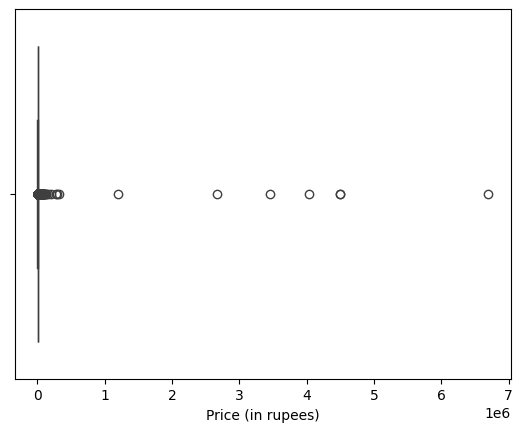

In [125]:
import seaborn as sns
sns.boxplot(x='Price (in rupees)' , data=df)

In [126]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df[["Price (in rupees)"]]=scaler.fit_transform(df[["Price (in rupees)"]])

In [127]:
df_encoded=pd.get_dummies(df,columns=["Furnishing","Transaction"])

In [128]:
import matplotlib.pyplot as plt

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 184508 entries, 0 to 187530
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              184508 non-null  int64  
 1   Title              184508 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  184508 non-null  object 
 4   Price (in rupees)  184508 non-null  float64
 5   location           184508 non-null  object 
 6   Carpet Area        184508 non-null  object 
 7   Status             184508 non-null  object 
 8   Floor              184508 non-null  object 
 9   Transaction        184508 non-null  object 
 10  Furnishing         184508 non-null  object 
 11  facing             184508 non-null  object 
 12  overlooking        184508 non-null  object 
 13  Society            184508 non-null  object 
 14  Bathroom           184508 non-null  object 
 15  Balcony            184508 non-null  object 
 16  Car Par

<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/1603341198.py:11: SyntaxWarning: invalid escape sequence '\d'
  df["Super Area"] = df["Super Area"].astype(str).str.extract("(\d+)").astype(float)
/tmp/ipykernel_55/1603341198.py:18: SyntaxWarning: invalid escape sequence '\d'
  df["Bathroom"] = df["Bathroom"].astype(str).str.extract("(\d+)").astype(float)


                   Price (in rupees)  Super Area  Bathroom
Price (in rupees)           1.000000    0.009465  0.058155
Super Area                  0.009465    1.000000  0.406756
Bathroom                    0.058155    0.406756  1.000000


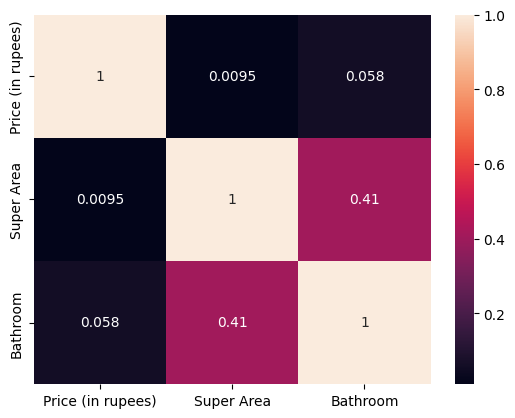

In [130]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# Convert Super Area to numeric
# ================================

# "1500 sqft" -> 1500
df["Super Area"] = df["Super Area"].astype(str).str.extract("(\d+)").astype(float)

# ================================
# Convert Bathroom to numeric
# ================================

# "2 Bathrooms" -> 2
df["Bathroom"] = df["Bathroom"].astype(str).str.extract("(\d+)").astype(float)

# ================================
# Create Correlation Matrix
# ================================

corr = df[["Price (in rupees)", "Super Area", "Bathroom"]].corr()

print(corr)

# ================================
# Plot Heatmap
# ================================

sns.heatmap(corr, annot=True)
plt.show()


In [132]:
# ================================
# Feature Engineering
# ================================

# Carpet Area clean:
# "1200 sqft" / "49 sqm" / "85 sq.ft"  -> 1200 / 49 / 85
df["Carpet Area"] = (
    df["Carpet Area"]
    .astype(str)
    .str.extract("(\d+)")
    .astype(float)
)

# Price per sqft = Price / Carpet Area
df["Price_per_sqft"] = df["Price (in rupees)"] / df["Carpet Area"]


<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55/2618921223.py:10: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")
